In [1]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
from metpy.units import units
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point, Polygon
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
from collections import OrderedDict
import sys

In [2]:
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Input data
# EURO-CORDEX RCMs
RCMs = OrderedDict() 
RCMs['CNRM-ALADIN64E1'] = {'projplot' : 'LambertConformal',
                           'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['HCLIM43-ALADIN'] = {'projplot' : 'LambertConformal',
                          'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['ALARO1-SFX'] = {'projplot' : 'LambertConformal',
                      'projplot_dict' : dict(central_longitude=9.9, central_latitude=49.0, standard_parallels=(33,45), false_easting = 3012.5, false_northing = 3012.5)}
RCMs['RACMO23E']   = {'projplot' : 'RotatedPole',
                      'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['ICON-CLM-202407-1-1'] = {'projplot' : 'RotatedPole',
                               'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['CCLM6-0-1'] = {'projplot' : 'RotatedPole',
                     'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['RegCM5-0'] = {'projplot' : 'RotatedPole',
                    'projplot_dict' : dict(pole_longitude=198, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['REMO2020-2-2'] = {'projplot' : 'RotatedPole',
                        'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['WRF451Q'] = {'projplot' : 'RotatedPole',
                   'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}

# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

## Biais des percentiles horaires: EURADCLIM AS A REFERENCE

In [5]:
folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_model = 'D:/EUROCORDEX_extremes/DATA/SIM/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']

name_obs = ['OBS_EURADCLIM_011EUi_2013-2022']


for agg in ['1','3','6','12']:
    for season in ['JJA','SON','DJF','MAM']:

        # load mask
        mask = np.load(f'D:/EUROCORDEX_extremes/DATA/OBS/mask_eurad_{season}.npy')

        for quantile in ['perc_99.00','perc_99.90']:
            for diff in ['rel','abs']:
                # Initialiser la figure et les axes
                fig, axes = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projplot})
            
                for obs in name_obs:
                    fObs = f'{obs}_{season}_all_{agg}h_perc.nc'
                    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
                    dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])
                    if(agg != '1'):
                        dsObs_cor = dsObs_cor.where(dsObs_cor != 0)
            
                    for ax, model in zip(axes.flat, name_models):
                        # reference file for the regridding
                        fMod = f'{model}1980-2020_{season}_all_{agg}h_perc.nc'
                
                        # aladin simulation to be regridded
                        dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

                        if model == 'ERA5_RegCM5-0':
                            dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

                        dsMod = dsMod.cf.add_bounds(["lon","lat"])
                        
                        # regrid obs
                        regridder = xe.Regridder(
                            dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
                        )
                        dsMod_regrid = regridder(dsMod, keep_attrs=True)

                        X = dsObs_cor.lon
                        Y = dsObs_cor.lat
                        ZOBS = dsObs_cor[quantile]
                        ZMOD = dsMod_regrid[quantile]
                        if(diff=="rel"):
                            Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference
                            Z = np.where(mask, np.nan, Z) # Set values outside the range to NaN
                            plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-65, vmax=65,
                                            transform=projorig, zorder=1)
                        else:
                            Z = ZMOD - ZOBS
                            Z = np.where(mask, np.nan, Z) # Set values outside the range to NaN
                            plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-6.5, vmax=6.5,
                                            transform=projorig, zorder=1)

                        ax.set_extent((-15, 38, 25, 70))  # France zoom
                        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)        # Draw coastlines
                        ax.add_feature(cfeature.OCEAN, facecolor='LightBlue', zorder=10)

                        # add model name
                        ax.set_title(label_models[name_models.index(model)], fontsize=10, pad=1.0)
                
                # Adjust the location of the subplots on the page to make room for the colorbar
                fig.subplots_adjust(right=0.8)

                # Add a colorbar axis at the bottom of the graph
                cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7]) #[left, bottom, width, height]
                cbar = fig.colorbar(plot, cax=cbar_ax,orientation='vertical',shrink=0.85, pad=0.05)
                if(diff=="rel"):
                    cbar.set_label("Relative difference (%)", fontsize=7.5)
                else:
                    cbar.set_label("Absolute difference (mm)", fontsize=7.5)

                cbar.ax.tick_params(labelsize=7.5)
                
                # save the figure
                plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_PERC_EURAD/precip_{agg}hr_{diff}diff_{quantile}_{season}.png', 
                            dpi=300, bbox_inches='tight')
                plt.close()

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.'

In [ ]:
from cProfile import label
from os import name


folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_model = 'D:/EUROCORDEX_extremes/DATA/SIM/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']

obs = 'OBS_COMEPHORE_011EUi_1997-2022'
label_obs = 'COMEPHORE'

for agg in ['1', '6']:
    for quantile in ['perc_99.90']:
        for season in ['JJA','SON','DJF','MAM']:

            df_main = {}
                
            # load obs
            fObs = f'{obs}_{season}_all_{agg}h_perc.nc'
            dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
            dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])
            if(agg != '1'):
                dsObs_cor = dsObs_cor.where(dsObs_cor != 0)
            
            for model in name_models:
                # reference file for the regridding
                fMod = f'{model}1980-2020_{season}_all_{agg}h_perc.nc'

                # aladin simulation to be regridded
                dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

                if model == 'ERA5_RegCM5-0':
                    dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

                dsMod = dsMod.cf.add_bounds(["lon","lat"])
                
                # regrid obs
                regridder = xe.Regridder(
                    dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
                )
                dsMod_regrid = regridder(dsMod, keep_attrs=True)

                X = dsObs_cor.lon
                Y = dsObs_cor.lat
                ZOBS = dsObs_cor[quantile]
                ZMOD = dsMod_regrid[quantile]
                Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference

                # add to data.frame
                df_main[model + '_' + obs] = Z.values.flatten()

            # !!! Note: for several obs -> fig, axes
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), layout="constrained")

            # for ax, obs in zip(axes.flat, name_obs):
            df = pd.DataFrame()

            # initialize vector of booleans
            isoutside = []

            for model in name_models:
                data_model = df_main[model + '_' + obs]

                # add to data.frame
                df[model] = data_model

                # check if outside the limits
                Q25 = np.nanpercentile(data_model, 25)
                Q75 = np.nanpercentile(data_model, 75)
                isoutside.append((Q25 < -100) | (Q75 > 100))
            
            # does not show outliers points (too many outliers)
            sns.boxplot(data=df, palette="Set3",showfliers=False, ax=ax)
                
            # loop over the boxes and change the color of the boxes that are outside the limits
            for i in range(len(name_models)):
                if isoutside[i]:
                    # Select which box you want to change    
                    mybox = ax.patches[i]

                    # Change the appearance of that box
                    mybox.set_edgecolor('red')
                    mybox.set_linewidth(5)

            # Set limits from 0 to 50
            ax.set_ylim(-200, 200)

            # change the orientation of the x-tick labels
            ax.set_xticks(ticks=range(len(label_models)), labels=label_models, rotation=45)

            ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)

            # export figure
            plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_BOXPLOT_COMEPHORE/precip_{agg}hr_boxplot_{label_obs}_{quantile}_{season}.png', 
                        dpi=300, bbox_inches='tight')
            plt.close()

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.'

## Biais des percentiles journaliers

In [ ]:
folder_obs = 'D:/EUROCORDEX_extremes/output_cnrm_apr/'
folder_model = 'D:/EUROCORDEX_extremes/output_juelich_apr/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']

name_obs = 'OBS_CERRALAND_011EUi_1986-2020'

for season in ['JJA','SON','DJF','MAM']:

    fObs = f'{name_obs}_{season}_all_24h_perc.nc'
    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
    dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])

    for quantile in ['perc_99.00','perc_99.90']:
        for diff in ['rel','abs']:
            # Initialiser la figure et les axes
            fig, axes = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projplot})

            for ax, model in zip(axes.flat, name_models):
                # reference file for the regridding
                fMod = f'{model}1980-2020_{season}_all_24h_perc.nc'
        
                # aladin simulation to be regridded
                dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

                if model == 'ERA5_RegCM5-0':
                    dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

                dsMod = dsMod.cf.add_bounds(["lon","lat"])
                
                # regrid obs
                regridder = xe.Regridder(
                    dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
                )
                dsMod_regrid = regridder(dsMod, keep_attrs=True)

                X = dsObs_cor.lon
                Y = dsObs_cor.lat
                ZOBS = dsObs_cor[quantile]
                ZMOD = dsMod_regrid[quantile]

                if(diff=="rel"):
                    Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference
                    plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-65, vmax=65,
                                    transform=projorig, zorder=1)
                else:
                    Z = ZMOD - ZOBS
                    plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-32.5, vmax=32.5,
                                    transform=projorig, zorder=1)

                ax.set_extent((-15,38, 25, 70))  # All Europe domain
                ax.add_feature(cfeature.COASTLINE, linewidth=0.5)        # Draw coastlines
                ax.set_title(label_models[name_models.index(model)], fontsize=10, pad=1.0)

            # Adjust the location of the subplots on the page to make room for the colorbar
            fig.subplots_adjust(right=0.8)

            # Add a colorbar axis at the bottom of the graph
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7]) #[left, bottom, width, height]
            cbar = fig.colorbar(plot, cax=cbar_ax,orientation='vertical',shrink=0.85, pad=0.05)
            if diff == "rel":
                cbar.set_label("Relative difference (%)", fontsize=7.5)
            else:
                cbar.set_label("Absolute difference (mm)", fontsize=7.5)
            
            cbar.ax.tick_params(labelsize=7.5)

            # save the figure
            plt.savefig(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_24h_{diff}diff_{quantile}_{season}.png', 
                        dpi=300, bbox_inches='tight')
            plt.close()


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.'

## try figure synthetic one row per season, one column per region

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


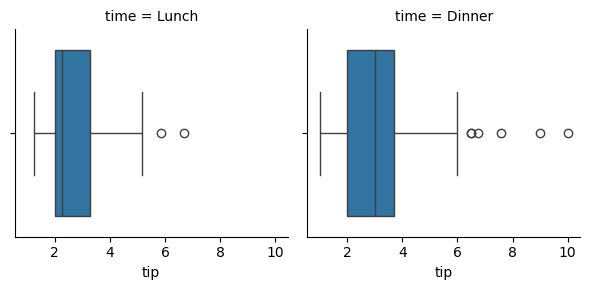

In [3]:
# https://seaborn.pydata.org/tutorial/axis_grids.html
tips = sns.load_dataset("tips")
g = sns.FacetGrid(tips, col="time")
g.map(sns.boxplot, "tip")


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.'

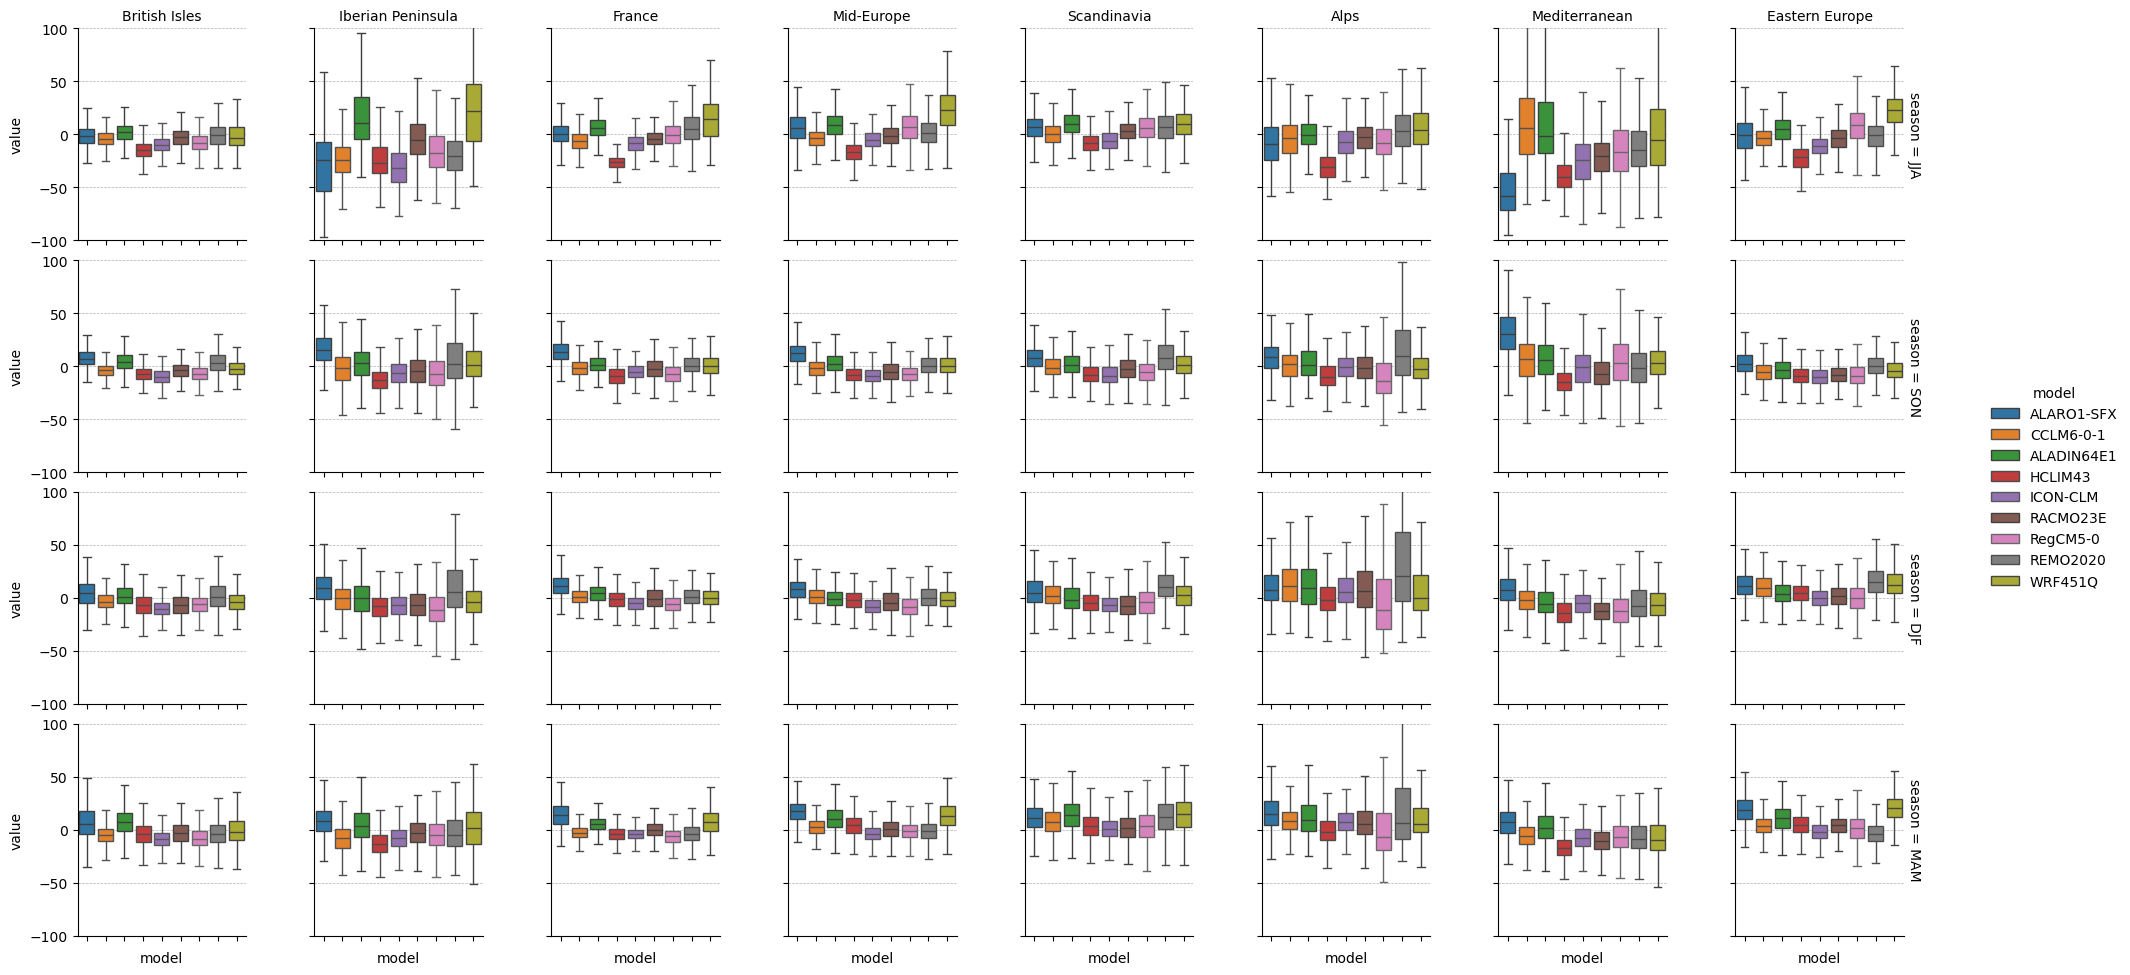

In [ ]:
gdf = gpd.read_file("regions.geojson")

folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_model = 'D:/EUROCORDEX_extremes/DATA/SIM/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']
name_obs = 'OBS_CERRALAND_011EUi_1986-2020'

# quantile to be used for the boxplot
quantile = 'perc_99.00'
             
# generate a fake df
# 1. Initialize an empty list
df_list = []

# 2. Run the loop to collect small dataframes
for ir, season in enumerate(['JJA','SON','DJF','MAM']):

    fObs = f'{name_obs}_{season}_all_24h_perc.nc'
    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
    dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])

    for ic, region in gdf.iterrows():
        for model in name_models:
            # corresponding label for the model
            model_label = label_models[name_models.index(model)]
            
            # reference file for the regridding
            fMod = f'{model}1980-2020_{season}_all_24h_perc.nc'

            # aladin simulation to be regridded
            dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

            if model == 'ERA5_RegCM5-0':
                dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

            dsMod = dsMod.cf.add_bounds(["lon","lat"])

            # regrid obs
            regridder = xe.Regridder(
                dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
            )
            dsMod_regrid = regridder(dsMod, keep_attrs=True)

            ZOBS = dsObs_cor[quantile]
            ZMOD = dsMod_regrid[quantile]
            Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference
            Z.rio.write_crs("EPSG:4326", inplace=True)

            # reproject the GeoDataFrame to match the CRS of the raster data
            gdf_proj = gdf.to_crs(Z.rio.crs)

            # prepare data for boxplot
            Zclip = Z.rio.clip([region['geometry']], crs=gdf_proj.crs)
            zvec = Zclip.values.flatten()
            nzvec = len(zvec)

            # Simulated dataframe generation
            small_df = pd.DataFrame({"season": [season]*nzvec, 
                                     "region": [region['names']]*nzvec,
                                     "model": [model_label]*nzvec, 
                                     "value": zvec})
            df_list.append(small_df)


# 3. Concatenate everything once after the loop
df_plot = pd.concat(df_list, ignore_index=True)
df_plot.to_csv(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_BOXPLOT_CERRA/boxplot_24h_reldiff_{quantile}.csv', index=False)

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


FileNotFoundError: [Errno 2] No such file or directory: 'D:/EUROCORDEX_extremes/DIFF_BOXPLOT_CERRA/boxplot_24h_reldiff_perc_99.00.png'

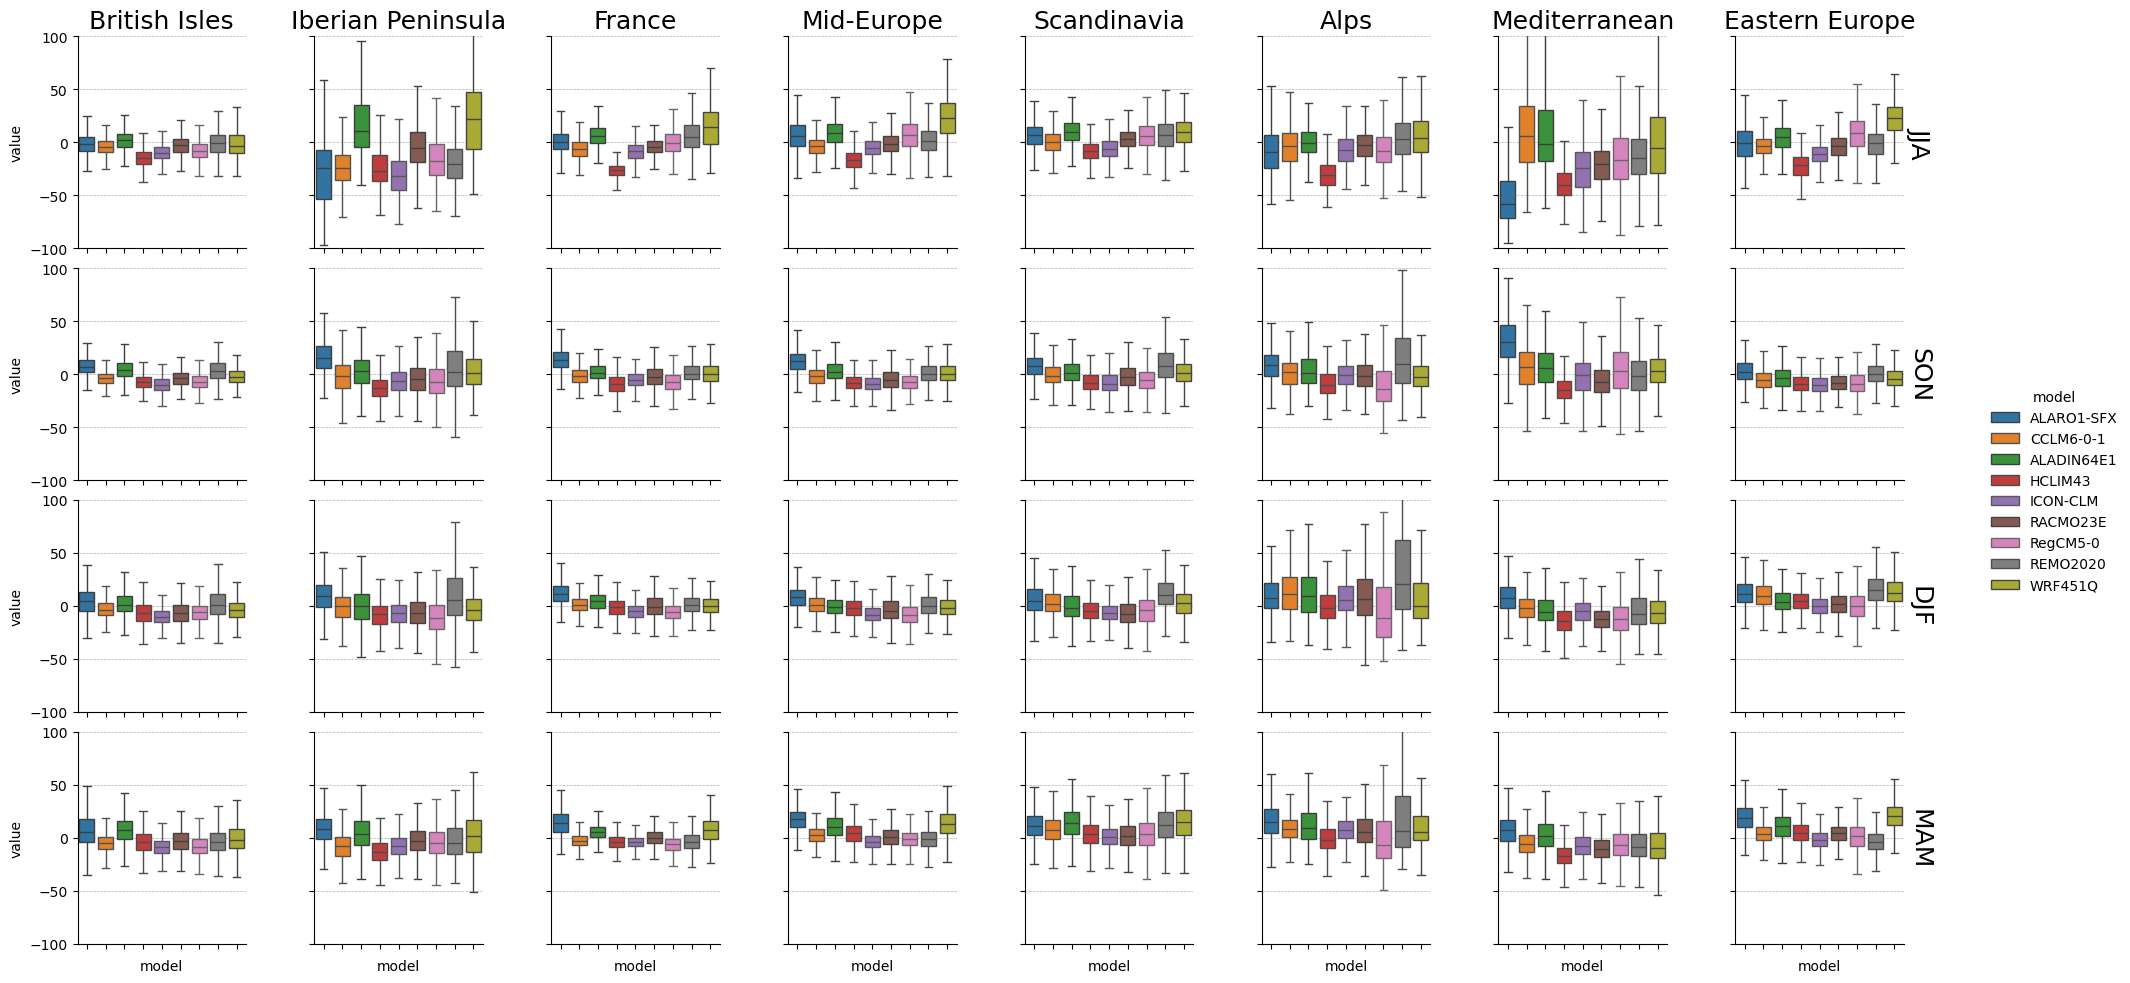

In [ ]:
g = sns.FacetGrid(df_plot, row="season",col="region", hue="model",margin_titles=True, height=2.5)
g.map(sns.boxplot, "model", "value", showfliers=False)
g.add_legend()
g.set(ylim=(-100, 100))

# Changes title from "your_column = value" to just "value"
g.set_titles(row_template="", col_template="")

for ax,m in zip(g.axes[0,:],methods):
    ax.set_title(m, fontweight='bold', fontsize=18)
for ax,l in zip(g.axes[:,0],['JJA','SON','DJF','MAM']):
    ax.set_ylabel(l, fontweight='bold', fontsize=18, rotation=0, ha='right', va='center')

plt.tight_layout() # automatically adjust spacing of axes

# Remove x-axis labels from all facets
for ax in g.axes.flatten():
    ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)
    ax.set_xticklabels("")

# save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_BOXPLOT_CERRA/boxplot_24h_reldiff_{quantile}.png', 
            dpi=300, bbox_inches='tight')

In [82]:
gdf = gpd.read_file("regions.geojson")

folder_obs = 'D:/EUROCORDEX_extremes/output_cnrm_apr/'
folder_model = 'D:/EUROCORDEX_extremes/output_juelich_apr/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']
name_obs = 'OBS_CERRALAND_011EUi_1986-2020'

for season in ['JJA','SON','DJF','MAM']:

    fObs = f'{name_obs}_{season}_all_24h_perc.nc'
    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
    dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])


    # prepare data for boxplot
    df_main = {}

    # LOOP 1: loop over models to load the data once per model and then loop over quantiles and regions to prepare the data for boxplot
    for model in name_models:

        # reference file for the regridding
        fMod = f'{model}1980-2020_{season}_all_24h_perc.nc'

        # aladin simulation to be regridded
        dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

        if model == 'ERA5_RegCM5-0':
            dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

        dsMod = dsMod.cf.add_bounds(["lon","lat"])

        # regrid obs
        regridder = xe.Regridder(
            dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
        )
        dsMod_regrid = regridder(dsMod, keep_attrs=True)

        for quantile in ['perc_99.00','perc_99.90']:
            ZOBS = dsObs_cor[quantile]
            ZMOD = dsMod_regrid[quantile]
            Z = (ZMOD / ZOBS - 1) * 100 # Calculate percentage difference
            Z.rio.write_crs("EPSG:4326", inplace=True)

            gdf_proj = gdf.to_crs(Z.rio.crs)

            for index, row in gdf_proj.iterrows():
                # prepare data for boxplot
                Zclip = Z.rio.clip([row['geometry']], crs=gdf_proj.crs)
                df_main[model + '_' + row.abbrevs + '_' + quantile] = Zclip.values.flatten()

    # LOOP 2: loop over the quantiles and produce figures 2 x 4 with one panel per region (x-axis: models, y-axis: relative difference) for each quantile and season
    for quantile in ['perc_99.00','perc_99.90']:
        fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8), layout="constrained")

        for ax, row in zip(axes.flat, gdf.itertuples()):
            df = pd.DataFrame()

            # initialize vector of booleans
            isoutside = []

            for model in name_models:
                data_model = df_main[model + '_' + row.abbrevs + '_' + quantile]

                # add to data.frame
                df[model] = data_model

                # check if outside the limits
                Q25 = np.nanpercentile(data_model, 25)
                Q75 = np.nanpercentile(data_model, 75)
                isoutside.append((Q25 < -100) | (Q75 > 100))
            
            # does not show outliers points (too many outliers)
            sns.boxplot(data=df, palette="Set3",showfliers=False, ax=ax)
                
            # loop over the boxes and change the color of the boxes that are outside the limits
            for i in range(len(name_models)):
                if isoutside[i]:
                    # Select which box you want to change    
                    mybox = ax.patches[i]

                    # Change the appearance of that box
                    mybox.set_edgecolor('red')
                    mybox.set_linewidth(5)

            # Set limits from 0 to 50
            ax.set_ylim(-100, 100)

            # add title with region name
            ax.set_title(row.names, fontsize=16)

            # change the orientation of the x-tick labels
            ax.set_xticks(ticks=range(len(label_models)), labels=label_models, rotation=45)

            ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)

        # export figure
        plt.savefig(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_24h_boxplot_{quantile}_{season}.png', dpi=300, bbox_inches='tight')
        plt.close()

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.'

In [83]:
ZOBS

<xarray.DataArray 'perc_99.90' (lat: 408, lon: 881)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(408, 881), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB 21.81 21.94 22.06 22.19 ... 72.44 72.56 72.69
  * lon      (lon) float64 7kB -44.81 -44.69 -44.56 -44.44 ... 64.94 65.06 65.19
Attributes:
    units:    mm day-1

## Simple scaling

In [84]:
def getScalingParameter(maxSeas):
    # pas de temps
    vec_pdt = [1,3,6,12,24,72]
    n_pdt = len(vec_pdt)

    # ordre moments
    vec_order = [i for i in np.arange(0.5, 4.5, 0.5)]
    n_order = len(vec_order)

    # get number of longitude and latitude points
    nLon = maxSeas.shape[2]
    nLat = maxSeas.shape[3]

    # STEP 0: rescale maxima to get the same unit for all pdt (mm/hour)
    for i_pdt in range(n_pdt):
        pdt = vec_pdt[i_pdt]
        
        # fill array
        maxSeas[:,i_pdt,:,:] = maxSeas[:,i_pdt,:,:] / pdt

    # matrix of moments for different order
    moment_mat = np.empty((nLon,nLat,n_pdt,n_order))
    scalingPar = np.empty((nLon,nLat))
    for iLon in range(nLon):
        for iLat in range(nLat):
        
            # STEP 1: compute moments for differents ordres
            for i_pdt in range(n_pdt):
                # pas de temps
                pdt = vec_pdt[i_pdt]
                
                # max pour tous les mois et tous les ans
                max_vec = maxSeas[:,i_pdt,iLon,iLat]
                
                # moments non-centre pour differents ordres: E[I^q(D,0)]
                for i_order in range(n_order):
                    order = vec_order[i_order]
                    moment_mat[iLon,iLat,i_pdt,i_order] = np.mean(max_vec**order)
                
            # STEP 2: apply linear regressions log(E_h^k) ~ a + kq*log(h) for each order
            kq = []
            for i_order in range(n_order):
                order = vec_order[i_order]
            
                # log of the moments and log of the pas de temps
                x = np.log(vec_pdt)
                y = np.log(moment_mat[iLon,iLat,:,i_order])

                # Perform regression
                reg_linear = stats.linregress(x, y)
                kq.append(reg_linear.slope)
            
            # STEP 3: apply linear regression  kq ~ k
            x = vec_order
            y = kq
            reg_linear = sm.OLS(y, x).fit()
            scalingPar[iLon,iLat] = -reg_linear.params

    return scalingPar

### Estimates for observations

In [85]:
folder_obs = 'D:/EUROCORDEX_extremes/output_cnrm_Apr/'
obs = 'OBS_COMEPHORE_011EUi_1997-2022'

for season in ["JJA","DJF"]:
    #for obs in name_obs:
    
    fObs = f'{obs}_{season}'
    dsObs = xr.load_dataset(folder_obs+fObs+"_max_scale_S1.nc", engine="netcdf4")
    
    scalingPar = getScalingParameter(dsObs.maxpr.values)
    dsObs = dsObs.cf.add_bounds(["lon","lat"])

    dsObs_cor = dsObs.drop_vars("maxpr")

    dsObs_cor["scalingPar"] = (("y", "x"), scalingPar)

    dsObs_cor.to_netcdf(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_{obs}_{season}.nc')

C:\Users\eving\AppData\Local\Temp\ipykernel_14892\156797655.py:8: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsObs = xr.load_dataset(folder_obs+fObs+"_max_scale_S1.nc", engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:47: RuntimeWarning: divide by zero encountered in log
  y = np.log(moment_mat[iLon,iLat,:,i_order])
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to 

In [4]:
folder_obs = 'D:/EUROCORDEX_extremes/output_cnrm/'
folder_model = 'D:/EUROCORDEX_extremes/output_juelich_apr/'
obs = 'OBS_COMEPHORE_011EUi_1997-2022'

for season in ["JJA","DJF"]:

  fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

  
  fObs = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_{obs}_{season}.nc'
  dsObs = xr.load_dataset(fObs, engine="netcdf4")

  X = dsObs.lon.values
  Y = dsObs.lat.values
  scalingPar = dsObs.scalingPar.values

  plot = ax.pcolormesh(X, Y, scalingPar, cmap="tab20b", vmin=0.2,vmax=1,transform=ccrs.PlateCarree(), zorder=1)

  # add coastlines
  ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
  ax.set_extent((-10, 13, 38, 54))  # France zoom
                        
  # add title
  ax.set_title('Obs. reference', fontsize=16)

  # 5. Add a colorbar and title
  fig.colorbar(plot, ax=ax, orientation='horizontal', shrink=0.5, pad=0.05, label='Scaling parameter (-)')

  # export figure
  plt.savefig(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_Obs_{season}.png', dpi=300, bbox_inches='tight')
  plt.close()


In [ ]:
folder_model = 'D:/EUROCORDEX_extremes/output_juelich_apr/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']

label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',u
              'RegCM5-0','REMO2020','WRF451Q']

for season in ["JJA","DJF"]:
  
  # loop over model
  for model in name_models:
    print("process data for model " + model + " and season " + season)
  
    fMod = f'{model}1980-2020_{season}'
    dsMod = xr.load_dataset(folder_model+fMod+"_max_scale_S1.nc", engine="netcdf4")

    if model == 'ERA5_RegCM5-0':
        dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

    scalingPar = getScalingParameter(dsMod.maxpr.values)

    dsMod = dsMod.cf.add_bounds(["lon","lat"])

    dsMod_cor = dsMod.drop_vars("maxpr")

    dsMod_cor["scalingPar"] = (("y", "x"), scalingPar)

    dsMod_cor.to_netcdf(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_{model}_{season}.nc')

process data for model ERA5_ALARO1-SFX and season JJA


C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2466716376.py:25: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_model+fMod+"_max_scale_S1.nc", engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

process data for model ERA5_CCLM6-0-1 and season JJA


C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2466716376.py:25: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_model+fMod+"_max_scale_S1.nc", engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

process data for model ERA5_CNRM-ALADIN64E1 and season JJA


...

C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2466716376.py:25: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_model+fMod+"_max_scale_S1.nc", engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

process data for model ERA5_REMO2020-2-2 and season DJF


C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2466716376.py:25: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_model+fMod+"_max_scale_S1.nc", engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

process data for model ERA5_WRF451Q and season DJF


C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2466716376.py:25: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_model+fMod+"_max_scale_S1.nc", engine="netcdf4")
C:\Users\eving\AppData\Local\Temp\ipykernel_14892\2704732992.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

In [10]:
folder_model = 'D:/EUROCORDEX_extremes/output_juelich_apr/'

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']

for season in ["JJA","DJF"]:
  
  fig, axes = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projplot})

  # loop over model
  for ax, model in zip(axes.flat, name_models):
  
    fMod = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_{model}_{season}.nc'
    dsMod = xr.load_dataset(fMod, engine="netcdf4")

    X = dsMod.lon.values
    Y = dsMod.lat.values
    scalingPar = dsMod.scalingPar.values

    plot = ax.pcolormesh(X, Y, scalingPar, cmap="tab20b", vmin=0.2,vmax=1,transform=projorig, zorder=1)

    ax.set_extent((-15,38, 25, 70))  # All Europe domain

    # add coastlines
    ax.add_feature(cfeature.COASTLINE, linewidth=1)

    # add title
    ax.set_title(label_models[name_models.index(model)], fontsize=10, pad=1.0)


  # Adjust the location of the subplots on the page to make room for the colorbar
  fig.subplots_adjust(right=0.8)

  # Add a colorbar axis at the bottom of the graph
  cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7]) #[left, bottom, width, height]
  cbar = fig.colorbar(plot, cax=cbar_ax,orientation='vertical',shrink=0.85, pad=0.05)
  cbar.set_label("Scaling par. (-)", fontsize=7.5)
  cbar.ax.tick_params(labelsize=7.5)

  # export figure
  plt.savefig(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_Model_{season}.png', dpi=300, bbox_inches='tight')
  plt.close()


In [ ]:
# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
              'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
              'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
              'HCLIM43','ICON-CLM','RACMO23E',
              'RegCM5-0','REMO2020','WRF451Q']


obs = 'OBS_COMEPHORE_011EUi_1997-2022'

for season in ["JJA","DJF"]:
    # Initialiser la figure et les axes
    fig, axes = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projplot})

    for ax, model in zip(axes.flat, name_models):

        # reference file for the regridding
        fMod = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_{model}_{season}.nc'
        dsMod = xr.load_dataset(fMod, engine="netcdf4")

        fObs = f'{obs}_{season}'
        
        fObs = f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_{obs}_{season}.nc'
        dsObs = xr.load_dataset(fObs, engine="netcdf4")

        dsMod_clean = xr.Dataset(
            data_vars={"scalingPar": (("y", "x"), dsMod.scalingPar.values)},
            coords={
                "x": dsMod.x,
                "y": dsMod.y,
                "lon": (("y", "x"), dsMod.lon.values),
                "lat": (("y", "x"), dsMod.lat.values),
            }
        )

        dsMod_clean = dsMod_clean.cf.add_bounds(["lon","lat"])
        
        # regrid obs
        regridder = xe.Regridder(
            dsMod_clean, dsObs, "conservative", unmapped_to_nan=True, ignore_degenerate=True
        )

        dsMod_regrid = regridder(dsMod_clean, keep_attrs=True)

        X = dsObs.lon
        Y = dsObs.lat

        ZOBS = dsObs.scalingPar.values
        ZMOD = dsMod_regrid.scalingPar.values
        Z = ZMOD - ZOBS

        plot = ax.pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-0.3,vmax=0.3,transform=projorig, zorder=1)
            
        # add coastlines
        ax.add_feature(cfeature.COASTLINE, linewidth=1)        # Draw coastlines

        # add model name
        ax.set_title(label_models[name_models.index(model)], fontsize=10, pad=1.0)

        ax.set_extent((-10, 13, 38, 54))  # France zoom
    
    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(right=0.8)

    # Add a colorbar axis at the bottom of the graph
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7]) #[left, bottom, width, height]
    cbar = fig.colorbar(plot, cax=cbar_ax,orientation='vertical',shrink=0.85, pad=0.05)
    cbar.set_label("Scaling par. (-)", fontsize=7.5)
    cbar.ax.tick_params(labelsize=7.5)

    # save the figure
    plt.savefig(f'D:/EUROCORDEX_extremes/figures_24Apr/precip_simplescaling_Bias_{season}.png', dpi=300, bbox_inches='tight')
    plt.close()

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:95: UserWarning: Variables {'rlat_bnds', 'rlon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\frontend.py:96: UserWarning: Variables {'rlat_bnds', 'rlon_bnds'} not found in object but are referred to in the CF attributes.
  lat_bnds = ds.cf.get_bounds('latitude')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affec

In [ ]:
dsMod_clean = xr.Dataset(
    data_vars={"scalingPar": (("y", "x"), dsMod.scalingPar.values)},
    coords={
        "x": dsMod.x,
        "y": dsMod.y,
        "lon": (("y", "x"), dsMod.lon.values),
        "lat": (("y", "x"), dsMod.lat.values),
    }
)

dsMod_clean = dsMod_clean.cf.add_bounds(["lon","lat"])

## figures to check simple scaling estimates

Text(0, 0.5, 'Latitude')

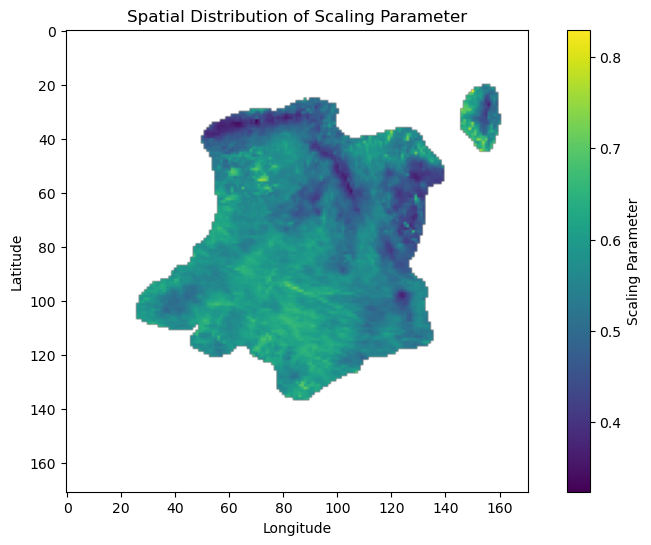

In [ ]:
iLon = 100
iLat = 100

# STEP 1: compute moments for differents ordres
for i_pdt in range(n_pdt):
    # pas de temps
    pdt = vec_pdt[i_pdt]
    
    # max pour tous les mois et tous les ans
    max_vec = maxSeas[:,i_pdt,iLon,iLat]
    
    # moments non-centre pour differents ordres: E[I^q(D,0)]
    for i_order in range(n_order):
        order = vec_order[i_order]
        moment_mat[iLon,iLat,i_pdt,i_order] = np.mean(max_vec**order)

# STEP 2: apply linear regressions log(E_h^k) ~ a + kq*log(h) for each order
kq = []
for i_order in range(n_order):
    order = vec_order[i_order]

    # log of the moments and log of the pas de temps
    x = np.log(vec_pdt)
    y = np.log(moment_mat[iLon,iLat,:,i_order])

    # Perform regression
    reg_linear = stats.linregress(x, y)
    kq.append(reg_linear.slope)

# STEP 3: apply linear regression  kq ~ k
x = vec_order
y = kq
reg_linear = sm.OLS(y, x).fit()
scalingPar[iLon,iLat] = -reg_linear.params

# log of the moments and log of the pas de temps
x = np.log(vec_pdt)
y = np.log(moment_mat[iLon,iLat,:,i_order])

# Perform regression
reg_linear = stats.linregress(x, y)

# plot regression
plt.scatter(x, y, label='Data points')
plt.plot(x, reg_linear.intercept + reg_linear.slope * x, color='red', label='Regression line')

x = vec_order
y = kq
reg_linear = sm.OLS(y, x).fit()

# plot regression
plt.scatter(x, y, label='Data points')
plt.plot(x, reg_linear.params * x, color='red', label='Regression line')

# simple map of the scaling parameter
plt.figure(figsize=(10, 6))
plt.imshow(scalingPar, cmap='viridis')
plt.colorbar(label='Scaling Parameter')
plt.title('Spatial Distribution of Scaling Parameter')
plt.xlabel('Longitude')
plt.ylabel('Latitude')